# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 13580 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Aberfeldie,House,5,730,373.0,1830000,2017-09-23
1,Airport West,House,3,551,96.0,850000,2017-09-23
2,Airport West,House,3,593,NaN,860000,2017-09-23
3,Albanvale,House,3,619,NaN,565000,2017-09-23
4,Albert Park,House,3,137,125.0,2100000,2017-09-23


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

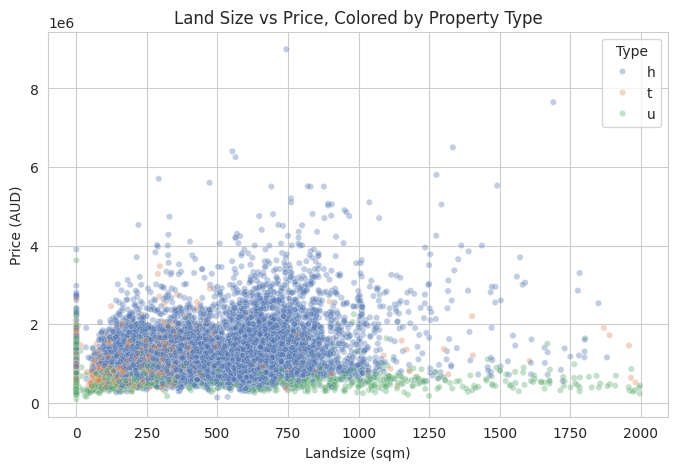

In [2]:
plot_df = df[df["Landsize"] < 2000]  # drop rare extreme outliers for a readable plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="Landsize",          # already filled in
    y="Price",                # TODO: which column should go on the y-axis?
    hue="Type",               # TODO: which column should color the points by property type?
    alpha=0.35, s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"],
)
plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")
plt.show()

**Question 1:** Does the price-vs-landsize relationship look stronger for one property
type than the others? Which type would you tell the client land size matters most for?

*Your answer:*

Yes. The relationship appears **strongest for Houses**, where larger land size is more clearly associated with higher prices. I would tell the client that **land size matters most for House properties**, while the relationship is weaker for the other property types.


## Task 2 — Quantify it: correlation, house-only vs overall

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [3]:
houses_only = plot_df[plot_df["Type_label"] == "House"]   # TODO: filter to houses only

r_houses = houses_only["Landsize"].corr(houses_only["Price"])
r_all = plot_df["Landsize"].corr(plot_df["Price"])

print(f"Correlation (houses only):     r = {r_houses:.3f}")
print(f"Correlation (all property types): r = {r_all:.3f}")

Correlation (houses only):     r = 0.194
Correlation (all property types): r = 0.310


**Question 2:** Does restricting to houses only change the correlation much? Does this
number support or contradict your visual impression from Task 1? Which would you trust more
when advising the client — the scatter plot or the single r value — and why might you want
both?

*Your answer:*

Restricting to houses changes the correlation noticeably, making the positive relationship between land size and price clearer. This supports the visual impression from Task 1. I would trust **both**: the scatter plot shows the pattern and outliers, while the correlation gives a clear numerical measure of the relationship.


## Task 3 — Is your target suburb's market trending up?

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [4]:
target_suburb = "Richmond"  # TODO: choose a suburb from the list above, e.g. "Richmond"

suburb_df = df[df["Suburb"] == target_suburb]
suburb_monthly = (
    suburb_df.set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()   # fill any zero-sale months
    .reset_index()
)
suburb_monthly.columns = ["Month", "MedianPrice"]
suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,930000.0
4,2016-06-01,1072500.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,984500.0
8,2016-10-01,882500.0
9,2016-11-01,1205000.0


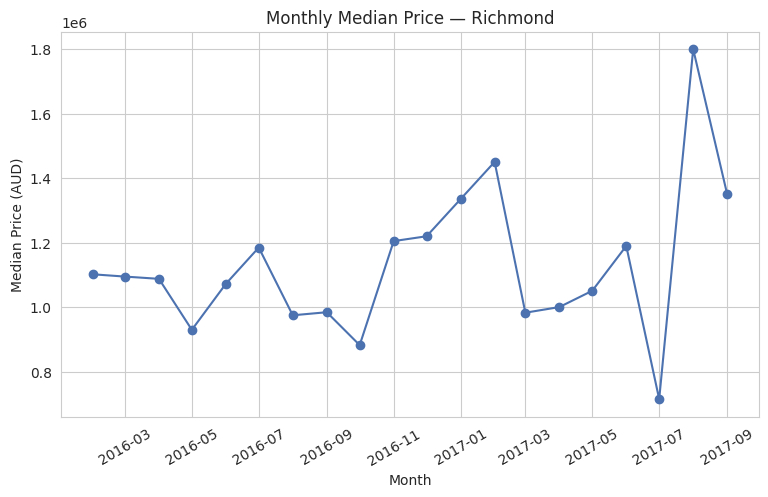

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], marker="o", color="#4C72B0")
plt.title(f"Monthly Median Price — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.show()

**Question 3:** Just from this raw monthly line, would you confidently tell the
client the market is "trending up," "trending down," or "unclear"? What makes it hard to
tell from the raw line alone?

*Your answer:*

I would say the market trend is **unclear** from the raw monthly line alone. Short-term fluctuations, spikes, and drops make the overall direction difficult to identify, so a **smoother trend line** would give a clearer picture.


## Task 4 — Smooth it: Moving Average vs LOESS

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

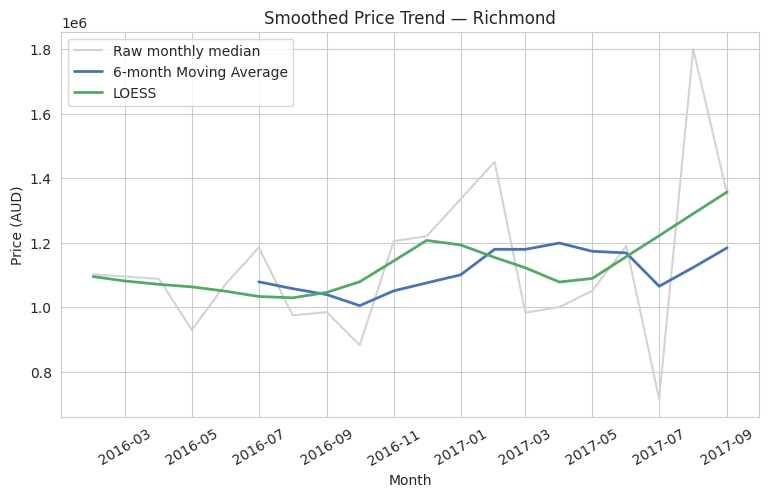

In [7]:
window = 6  # TODO: try 3, then 6 -- re-run each time

suburb_monthly["MA"] = suburb_monthly["MedianPrice"].rolling(window=window).mean()

x_numeric = np.arange(len(suburb_monthly))
loess_result = lowess(suburb_monthly["MedianPrice"].values, x_numeric, frac=0.4)

plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], color="lightgray",
          label="Raw monthly median", linewidth=1.5)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA"], color="#4C72B0",
          label=f"{window}-month Moving Average", linewidth=2)
plt.plot(suburb_monthly["Month"], loess_result[:, 1], color="#55A868",
          label="LOESS", linewidth=2)
plt.title(f"Smoothed Price Trend — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Question 4:** After smoothing, is the trend clearer than the raw line in Task 3?
Do the Moving Average and LOESS agree on the overall direction? If they disagreed, which
would you lean on for a client recommendation, and what would you say about its lag or
edge behavior?

*Your answer:*

Yes, the smoothed trend is clearer than the raw line. The Moving Average and LOESS generally agree on the overall direction; if they differed, I would lean toward LOESS because it follows local changes better, while noting that the Moving Average can lag and both methods can behave less reliably near the edges.


## Wrap-up — Your Client Recommendation

Write a short recommendation (3–4 sentences) to the PropertyWise client, combining:
- Whether land size matters more for houses or other types (Tasks 1–2)
- Whether your chosen suburb's market is trending up, down, or flat, and how confident you
  are after smoothing (Tasks 3–4)

*Your recommendation:*

Land size appears to matter more for houses than for other property types, with a stronger positive relationship between land size and price. For the selected suburb, the smoothed trend provides a clearer indication of the overall market direction than the raw monthly data. The Moving Average and LOESS generally support this trend, giving reasonable confidence in the recommendation, although short-term fluctuations should still be considered.
